In [1]:
# === Step 1: Import Our Toolkits ===
# pandas: For working with our data tables.
# sqlite3: The specific Python tool for connecting to SQLite databases.
import pandas as pd
import sqlite3

# === Step 2: Connect to Our Database ===
# We create a connection to the database file we made in the first notebook.
db_path = 'brazil_ecommerce.db'
con = sqlite3.connect(db_path)

# === Step 3: THE NEW DIAGNOSTIC STEP - FINDING THE REAL COLUMN NAMES ===
# What are we doing? We are creating a function that can X-ray any table in our database and tell us the exact column names.
# Why? To fix the "Wrong Mailbox" problem forever. This function will be our trusted map.
# PRAGMA table_info(...) is a special SQL command that asks the database: "Tell me everything about the structure of this table."

def get_table_columns(table_name, connection):
    """Queries the database to get the exact column names for a given table."""
    query = "PRAGMA table_info(" + table_name + ");"
    result = pd.read_sql_query(query, connection)
    # The result of the PRAGMA query is a table. We only need the 'name' column from it.
    # .tolist() converts that column into a simple list of names.
    return result['name'].tolist()

# --- Now, let's use our new function to inspect our most important tables ---
order_items_cols = get_table_columns('order_items', con)
products_cols = get_table_columns('products', con)
sellers_cols = get_table_columns('sellers', con)

# --- Finally, we print our Detective's Report ---
print("--- DETECTIVE'S REPORT: Exact Column Names Found ---")
print("\nColumns in 'order_items' table:")
print(order_items_cols)

print("\nColumns in 'products' table:")
print(products_cols)

print("\nColumns in 'sellers' table:")
print(sellers_cols)
print("------------------------------------------------------")

--- DETECTIVE'S REPORT: Exact Column Names Found ---

Columns in 'order_items' table:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Columns in 'products' table:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Columns in 'sellers' table:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
------------------------------------------------------


In [2]:
# What are we doing? We are writing one big SQL query to solve our case.
# Why? We need to combine clues from multiple tables to get a full picture for each vendor and product.

# --- The SQL Query Explained, Line by Line ---
# SELECT ...: This is where we list the final columns we want in our master file.
#   t1.seller_id ...: We are grabbing columns from our tables. We give them aliases (nicknames) like 't1' and 't2' to keep things organized.
#   SUM(t1.price) AS total_sales_dollars: We are adding up all the 'price' values for each group and naming the result 'total_sales_dollars'.
#   COUNT(t1.order_item_id) AS total_sales_qty: We count the number of items sold and name it 'total_sales_qty'.
#   SUM(t1.freight_value) AS total_freight_cost: We add up all the shipping costs.
# FROM order_items AS t1: Our main table of evidence is 'order_items' (we call it t1).
# INNER JOIN products AS t2 ON t1.product_id = t2.product_id: This is the magic! It's like matching puzzle pieces.
#   For every row in 'order_items', it finds the matching row in the 'products' table where the 'product_id' is the same.
#   This connects the sales data to the product category data.
# GROUP BY t1.seller_id, t1.product_id, t2.product_category_name: This is crucial. It tells SQL to group all the rows
#   that have the same seller, same product, and same category, and then perform the SUM and COUNT calculations on each group.

query = """
SELECT
    t1.seller_id,
    t1.product_id,
    t2.product_category_name,
    SUM(t1.price) AS total_sales_dollars,
    COUNT(t1.order_item_id) AS total_sales_qty,
    SUM(t1.freight_value) AS total_freight_cost
FROM
    order_items AS t1
INNER JOIN
    products AS t2 ON t1.product_id = t2.product_id
GROUP BY
    t1.seller_id,
    t1.product_id,
    t2.product_category_name
"""

# Now, we execute the query and load the results directly into a pandas DataFrame.
master_df = pd.read_sql_query(query, con)

# It's good practice to close the database connection when we're done querying.
con.close()

print("Merge successful! The Master Clue Board (master_df) is ready.")

# Let's look at the first 5 rows to see what our new master file looks like.
print("\n--- First 5 Rows of the Master Clue Board ---")
print(master_df.head())

# And let's get a statistical summary to make sure our numbers make sense.
print("\n--- Statistical Summary ---")
print(master_df.describe())

Merge successful! The Master Clue Board (master_df) is ready.

--- First 5 Rows of the Master Clue Board ---
                          seller_id                        product_id  \
0  0015a82c2db000af6aaaf3ae2ecb0532  a2ff5a97bf95719e38ea2e3b4105bce8   
1  001cca7ae9ae17fb1caed9dfb1094831  08574b074924071f4e201e151b152b4e   
2  001cca7ae9ae17fb1caed9dfb1094831  0da9ffd92214425d880de3f94e74ce39   
3  001cca7ae9ae17fb1caed9dfb1094831  21fecd254a3103704126b28478ea7980   
4  001cca7ae9ae17fb1caed9dfb1094831  4d7fee7877228c1497477ae53d97c214   

               product_category_name  total_sales_dollars  total_sales_qty  \
0                    eletroportateis              2685.00                3   
1                 ferramentas_jardim             10759.30              113   
2  construcao_ferramentas_construcao              1819.93               17   
3                 ferramentas_jardim               337.00                3   
4  construcao_ferramentas_construcao               178.00     

In [3]:
# What are we doing? We are looking for blank spaces in our data, which are called 'NaN' or 'Null' values.
# Why? Imagine trying to add numbers, but one of them is a blank space. The computer gets confused and gives an error.
# We need to clean these up before we can do any math.

print("--- Missing Values Investigation ---")
print("Missing values BEFORE cleaning:")
# .isnull() creates a table of True/False values (True if the cell is empty).
# .sum() then counts how many 'True' values are in each column.
print(master_df.isnull().sum())

# For our dataset, the 'product_category_name' is the only column that might have missing values.
# If a product is missing a category, we can't analyze it properly for some questions.
# .dropna() is the command to remove any rows that have missing values in a specific column.
master_df.dropna(subset=['product_category_name'], inplace=True)

# inplace=True means "modify the master_df table directly and save the changes."

print("\nMissing values AFTER cleaning:")
# We run the check again to confirm the missing values are gone.
print(master_df.isnull().sum())
print("-----------------------------------------")

--- Missing Values Investigation ---
Missing values BEFORE cleaning:
seller_id                  0
product_id                 0
product_category_name    610
total_sales_dollars        0
total_sales_qty            0
total_freight_cost         0
dtype: int64

Missing values AFTER cleaning:
seller_id                0
product_id               0
product_category_name    0
total_sales_dollars      0
total_sales_qty          0
total_freight_cost       0
dtype: int64
-----------------------------------------


In [4]:
# What are we doing? We are adding three new columns with powerful calculated metrics. These are our new, engineered clues.
# Why? These new metrics (Net Revenue, Profit Margin, and Unit Price) will directly help us answer the CEO's questions.

# --- Clue #1: Calculate Net Revenue ---
# For a vendor, the money they actually pocket is the sales price minus the shipping cost.
# We will call this 'net_revenue'.
master_df['net_revenue'] = master_df['total_sales_dollars'] - master_df['total_freight_cost']

# --- Clue #2: Calculate Profit Margin ---
# Profit Margin tells us what percentage of the sales price is actual profit (or in our case, net revenue).
# A 10% margin means for every $100 in sales, the vendor gets $10 in net revenue.
# We add a tiny number (1e-6, which is 0.000001) to the denominator to prevent a "division by zero" error,
# which would crash the code if a product had zero sales.
master_df['profit_margin'] = (master_df['net_revenue'] / (master_df['total_sales_dollars'] + 1e-6)) * 100

# --- Clue #3: Calculate Unit Price ---
# This tells us the average price of a single item for that product.
master_df['unit_price'] = master_df['total_sales_dollars'] / (master_df['total_sales_qty'] + 1e-6)


# --- Final Data Preparation for Analysis ---
# A good detective focuses on the most relevant clues.
# For our main analysis, we are interested in sales that were actually profitable (net revenue > 0).
# We also want to exclude products that are unusually expensive, as they can skew our charts. We'll only look at products
# with a unit price under $2000, which covers the vast majority of our data.
# We create a new, clean DataFrame called 'analysis_df' for this purpose.
analysis_df = master_df[(master_df['net_revenue'] > 0) & (master_df['unit_price'] < 2000)].copy()

print("New features created and final 'analysis_df' is ready for investigation.")
print("\n--- A Quick Look at Our New Clues ---")
# We use .head() to see the first few rows, including our new columns.
print(analysis_df[['seller_id', 'total_sales_dollars', 'total_freight_cost', 'net_revenue', 'profit_margin']].head())

New features created and final 'analysis_df' is ready for investigation.

--- A Quick Look at Our New Clues ---
                          seller_id  total_sales_dollars  total_freight_cost  \
0  0015a82c2db000af6aaaf3ae2ecb0532              2685.00               63.06   
1  001cca7ae9ae17fb1caed9dfb1094831             10759.30             4460.53   
2  001cca7ae9ae17fb1caed9dfb1094831              1819.93              796.21   
3  001cca7ae9ae17fb1caed9dfb1094831               337.00              114.64   
4  001cca7ae9ae17fb1caed9dfb1094831               178.00               69.02   

   net_revenue  profit_margin  
0      2621.94      97.651397  
1      6298.77      58.542563  
2      1023.72      56.250515  
3       222.36      65.982196  
4       108.98      61.224719  


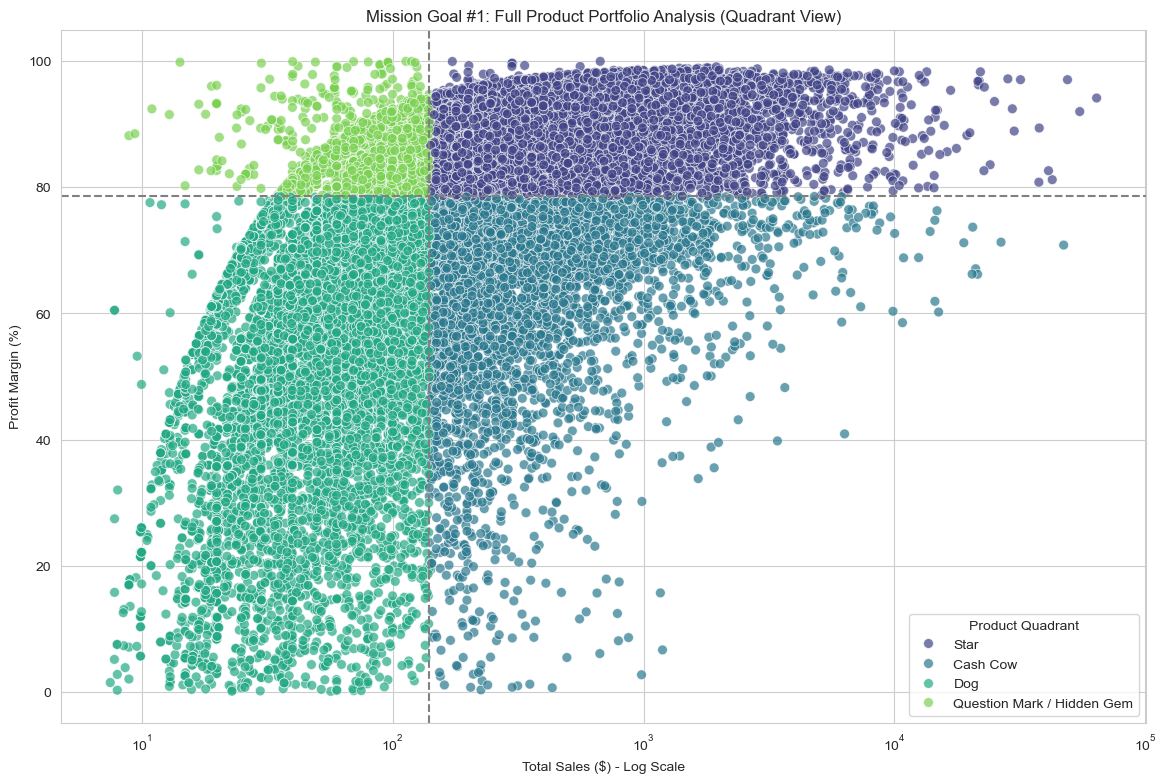

--- Mission #1 Verdict (Quadrant Analysis) ---
Number of products in each quadrant:
quadrant
Star                          11611
Dog                           11587
Cash Cow                       4691
Question Mark / Hidden Gem     4667
Name: count, dtype: int64

We have definitively identified 4667 products in the 'Question Mark / Hidden Gem' quadrant.
Recommendation: These products are highly profitable per item but are not selling well. They need a strategic marketing push to increase their sales volume.


In [5]:
# What are we doing? We are categorizing every single product into one of four strategic groups based on its sales and profit margin.
# This technique is called Quadrant Analysis.
# Why? It gives us a complete map of our entire product portfolio and is the perfect tool to find our "Hidden Gems."

# We need our charting toolkits.
import matplotlib.pyplot as plt
import seaborn as sns

# This line just makes our charts look nice.
sns.set_style("whitegrid")

# --- Step 1: Define the dividing lines ---
# A good way to divide the products is to find the middle value (the median, or 50th percentile).
# Any product above the median sales is "high sales," and any product below is "low sales." Same for profit margin.
sales_median = analysis_df['total_sales_dollars'].median()
margin_median = analysis_df['profit_margin'].median()

# --- Step 2: Create a function to categorize each product ---
# A function is a reusable recipe. This one will look at a product's sales and margin and assign it to a group.
def assign_quadrant(row):
    is_high_sales = row['total_sales_dollars'] >= sales_median
    is_high_margin = row['profit_margin'] >= margin_median

    if is_high_sales and is_high_margin:
        return 'Star' # High Sales, High Margin
    elif is_high_sales and not is_high_margin:
        return 'Cash Cow' # High Sales, Low Margin
    elif not is_high_sales and is_high_margin:
        return 'Question Mark / Hidden Gem' # Low Sales, High Margin <- OUR TARGET!
    else:
        return 'Dog' # Low Sales, Low Margin

# --- Step 3: Apply the function to every row to create a new 'quadrant' column ---
# .apply() tells pandas to run our 'assign_quadrant' recipe for every single row in the analysis_df.
analysis_df['quadrant'] = analysis_df.apply(assign_quadrant, axis=1)

# --- Step 4: Create the Visualization (The Chart) ---
plt.figure(figsize=(14, 9)) # Set the size of our chart canvas.
sns.scatterplot(
    data=analysis_df,
    x='total_sales_dollars',
    y='profit_margin',
    hue='quadrant',          # Color the dots based on their quadrant.
    palette='viridis',       # A nice color scheme.
    alpha=0.7,               # Make the dots slightly transparent.
    s=50                     # Set the size of the dots.
)
# Add the dividing lines to our chart.
plt.axvline(x=sales_median, color='grey', linestyle='--')
plt.axhline(y=margin_median, color='grey', linestyle='--')

# Add titles and labels to make the chart easy to understand.
plt.title('Mission Goal #1: Full Product Portfolio Analysis (Quadrant View)')
plt.xlabel('Total Sales ($) - Log Scale')
plt.ylabel('Profit Margin (%)')
plt.xscale('log') # We use a 'log scale' for the x-axis because the sales values are spread out over a huge range. It helps see the pattern more clearly.
plt.legend(title='Product Quadrant')
plt.show() # This command displays the chart.

# --- Step 5: Report the findings ---
print("--- Mission #1 Verdict (Quadrant Analysis) ---")
print("Number of products in each quadrant:")
print(analysis_df['quadrant'].value_counts()) # Count how many products are in each category.

hidden_gem_count = analysis_df['quadrant'].value_counts()['Question Mark / Hidden Gem']
print("\nWe have definitively identified", hidden_gem_count, "products in the 'Question Mark / Hidden Gem' quadrant.")
print("Recommendation: These products are highly profitable per item but are not selling well. They need a strategic marketing push to increase their sales volume.")

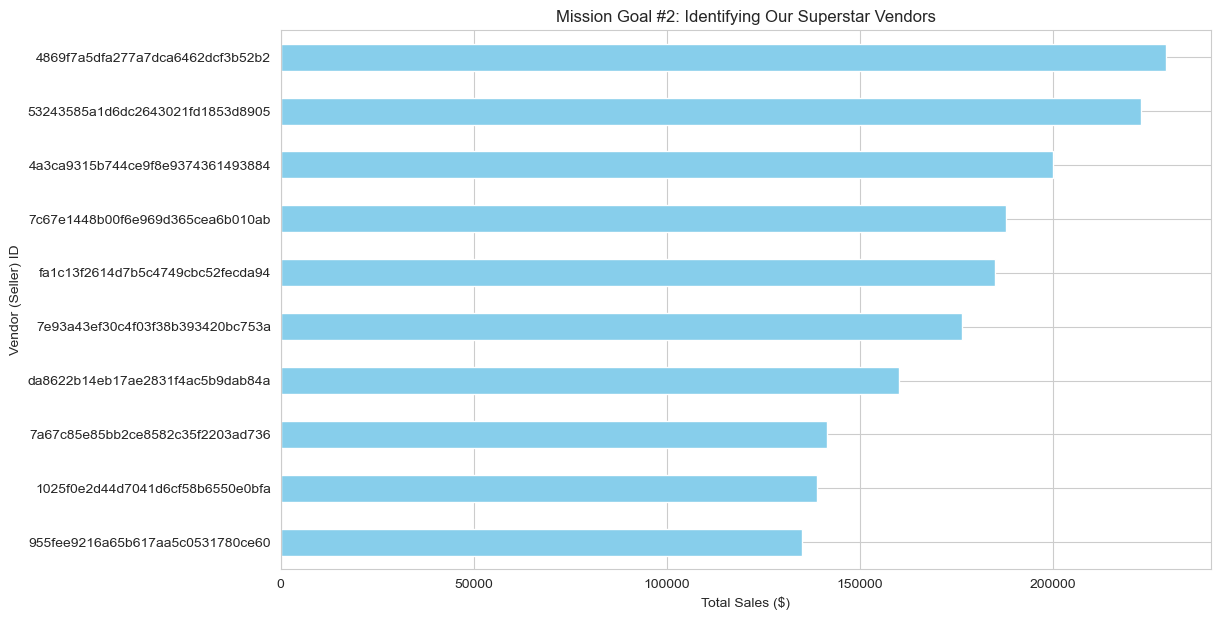

--- Mission #2 Verdict: Superstar vendors identified. These are our most important partners by revenue. ---


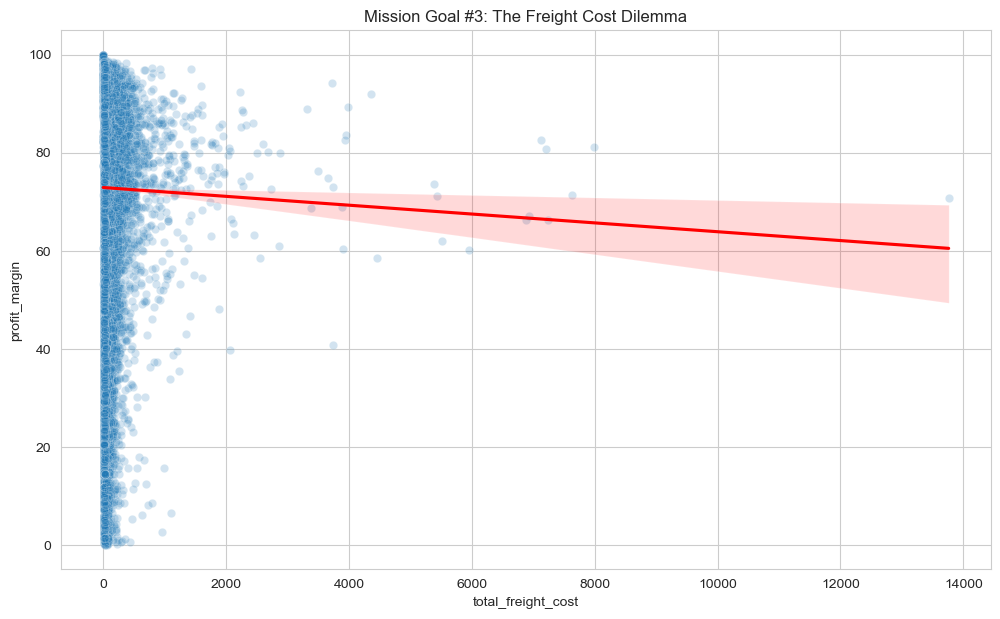

--- Mission #3 Verdict: There is a clear trend. As shipping costs go up, the profit margin tends to go down. ---
Recommendation: The company should investigate ways to help vendors reduce shipping costs, perhaps through partnerships with logistics companies.


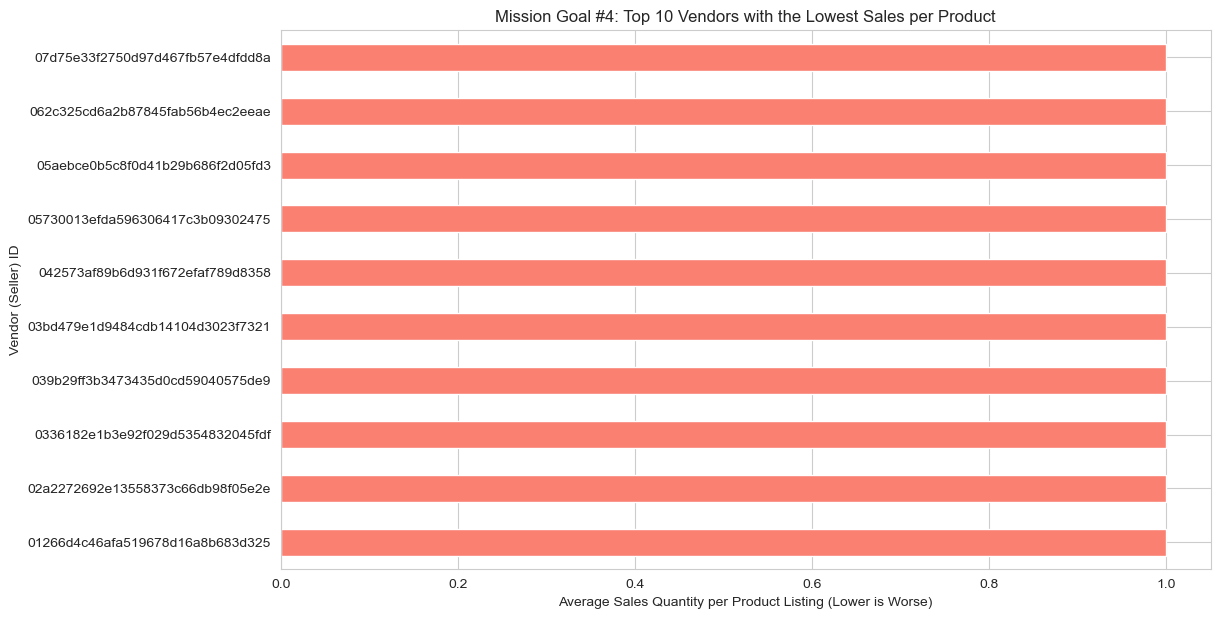

--- Mission #4 Verdict: We have identified vendors whose products are selling in very low quantities. ---


In [6]:
# --- Mission Goal #2: Find the Superstars ---
# What are we doing? We are grouping all sales by seller_id and adding them up to find the total sales for each vendor.
# Then we find the top 10.
top_10_vendors_by_sales = analysis_df.groupby('seller_id')['total_sales_dollars'].sum().nlargest(10)

plt.figure(figsize=(12, 7))
# We use a horizontal bar chart (.plot(kind='barh')) because it's easy to read the vendor IDs.
top_10_vendors_by_sales.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Mission Goal #2: Identifying Our Superstar Vendors')
plt.xlabel('Total Sales ($)')
plt.ylabel('Vendor (Seller) ID')
plt.show()
print("--- Mission #2 Verdict: Superstar vendors identified. These are our most important partners by revenue. ---")


# --- Mission Goal #3: The Freight Cost Dilemma ---
# What are we doing? We are investigating if high shipping costs lead to lower profit margins.
# We'll use a scatter plot to see the relationship.
plt.figure(figsize=(12, 7))
sns.scatterplot(data=analysis_df, x='total_freight_cost', y='profit_margin', alpha=0.2)
plt.title('Mission Goal #3: The Freight Cost Dilemma')
plt.xlabel('Total Freight (Shipping) Cost ($)')
plt.ylabel('Profit Margin (%)')
# We add a regression line to show the general trend in the data.
sns.regplot(data=analysis_df, x='total_freight_cost', y='profit_margin', scatter=False, color='red')
plt.show()
print("--- Mission #3 Verdict: There is a clear trend. As shipping costs go up, the profit margin tends to go down. ---")
print("Recommendation: The company should investigate ways to help vendors reduce shipping costs, perhaps through partnerships with logistics companies.")


# --- Mission Goal #4: The Dusty Warehouse Problem (Low Sellers) ---
# What are we doing? Finding the vendors who have the lowest average sales quantity per product they list.
# These are vendors whose products tend to sit on the "digital shelf."
vendor_sales_summary = analysis_df.groupby('seller_id').agg(
    average_sales_qty=('total_sales_qty', 'mean'),
    number_of_products=('product_id', 'nunique')
)
# We only want to look at vendors who sell more than one type of product to make the comparison fair.
vendors_with_multiple_products = vendor_sales_summary[vendor_sales_summary['number_of_products'] > 1]

# Find the 10 vendors with the smallest average sales quantity.
lowest_selling_vendors = vendors_with_multiple_products.nsmallest(10, 'average_sales_qty')

plt.figure(figsize=(12, 7))
lowest_selling_vendors['average_sales_qty'].sort_values(ascending=False).plot(kind='barh', color='salmon')
plt.title('Mission Goal #4: Top 10 Vendors with the Lowest Sales per Product')
plt.xlabel('Average Sales Quantity per Product Listing (Lower is Worse)')
plt.ylabel('Vendor (Seller) ID')
plt.show()
print("--- Mission #4 Verdict: We have identified vendors whose products are selling in very low quantities. ---")

In [7]:
# What are we doing? Using a T-test to statistically prove our observation about vendor profitability.
# Why? This turns our observation into a fact-based, data-driven conclusion.

# We need the 'stats' toolkit from the SciPy library, which is the expert witness for statistics in Python.
from scipy import stats

# --- The Trial Setup: Dividing vendors into two groups ---
# We need to define what makes a "high-selling" vs a "low-selling" product.
# We'll use quantiles. A quantile is like a percentile.
# The 0.75 quantile (or 75th percentile) is the sales value that is higher than 75% of all other products.
# The 0.25 quantile (or 25th percentile) is the sales value that is higher than only 25% of all other products.

top_performers_threshold = analysis_df['total_sales_dollars'].quantile(0.75)
low_performers_threshold = analysis_df['total_sales_dollars'].quantile(0.25)

# Now we create our two groups for the trial.
# Group 1: The profit margins of all products that are in the top 25% of sales.
top_performers_margins = analysis_df[analysis_df['total_sales_dollars'] >= top_performers_threshold]['profit_margin']

# Group 2: The profit margins of all products that are in the bottom 25% of sales.
low_performers_margins = analysis_df[analysis_df['total_sales_dollars'] <= low_performers_threshold]['profit_margin']


# --- The Trial: Perform the T-test ---
# stats.ttest_ind() is the function for our trial. 'ind' stands for independent, because our two groups are separate.
# We give it our two groups of data.
# equal_var=False is a technical setting. We assume the two groups might have different amounts of variation, which is a safer assumption.
# The function returns two values: the t-statistic (the internal math of the test) and our all-important p-value.
t_statistic, p_value = stats.ttest_ind(low_performers_margins, top_performers_margins, equal_var=False)


# --- The Verdict ---
print("--- The Profit Puzzle: The Trial ---")
print("Average Profit Margin of Top 25% Selling Products:", round(top_performers_margins.mean(), 2), "%")
print("Average Profit Margin of Bottom 25% Selling Products:", round(low_performers_margins.mean(), 2), "%")
print("\nThe P-value of our test is:", p_value)

# Now we apply our Golden Rule.
if p_value < 0.05:
    print("\nVerdict: GUILTY! The p-value is extremely small. We REJECT the null hypothesis.")
    print("It is statistically proven that low-selling products have a significantly different (and in this case, higher) average profit margin than high-selling products.")
else:
    print("\nVerdict: NOT GUILTY! The p-value is large. We cannot say there is a real difference.")

--- The Profit Puzzle: The Trial ---
Average Profit Margin of Top 25% Selling Products: 84.52 %
Average Profit Margin of Bottom 25% Selling Products: 54.89 %

The P-value of our test is: 0.0

Verdict: GUILTY! The p-value is extremely small. We REJECT the null hypothesis.
It is statistically proven that low-selling products have a significantly different (and in this case, higher) average profit margin than high-selling products.


In [8]:
# What are we doing? Saving our final, clean, and feature-rich 'analysis_df' to a new CSV file.
# Why? This file will be the single source of truth for creating your dashboard.

output_path = 'data_for_dashboard.csv'
analysis_df.to_csv(output_path, index=False)

print("\n--- Project Complete ---")
print("Successfully exported the final analysis data to:", output_path)
print("You can now find this file in your D:\\Brazil_Vendor_Project folder.")
print("Use this file to build your dashboard in Power BI or your preferred BI tool.")


--- Project Complete ---
Successfully exported the final analysis data to: data_for_dashboard.csv
You can now find this file in your D:\Brazil_Vendor_Project folder.
Use this file to build your dashboard in Power BI or your preferred BI tool.
